# Channelised drainage

In the [previous tutorial](01-greenland-outlet-glacier.ipynb) we showed that under low basal melt, the subglacial drainage system is entirely governed by the distributed sheet.
But Greenland outlet glaciers receive far more water during summer — surface melt rates can exceed 1 m/yr.
At these higher fluxes, the energy dissipated by turbulent water flow is enough to melt channels into the ice base, creating an **efficient drainage system** that coexists with the sheet.

In this tutorial we will:

1. Introduce the channel equations — how Röthlisberger channels open by dissipation-driven melting and close by ice creep.
2. Show how the drainage system transitions from sheet-dominated to channel-dominated as melt increases.
3. Visualise the channel network using hydropack's edge-plotting tools.

## The channel equations

Channels in GlaDS are discrete conduits that live on **mesh edges** (the Crouzeix–Raviart function space).
Each edge carries a channel with cross-sectional area $S(t)$.
The channel couples to the sheet through flux exchange and shared pressure.

### Channel discharge

Water flows through a channel with discharge:

$$Q = -k_c\, S^\alpha\, \left|\frac{\partial\phi}{\partial s}\right|^{\beta - 2}\, \frac{\partial\phi}{\partial s}$$

where $\partial\phi/\partial s$ is the hydraulic potential gradient along the edge, and $k_c$ is the channel conductivity.

### Channel area evolution

The channel area evolves as a competition between melting (opening) and creep (closing):

$$\frac{\partial S}{\partial t} = \frac{\Xi - \Pi}{\rho_i L} - \frac{2A}{n^n}\, S\, N^3$$

**Dissipation-driven opening** $\Xi$: the energy released by turbulent flow melts the channel walls:

$$\Xi = |Q\, \partial\phi/\partial s| + |l_c\, q_c\, \partial\phi/\partial s|$$

where the first term is the channel's own dissipation and the second is the contribution from sheet flow beneath the channel (of width $l_c$).

**Pressure-melting correction** $\Pi$: heat exchange with the ice due to the Clausius–Clapeyron relation:

$$\Pi = -c_t\, c_w\, \rho_w\, Q\, \frac{\partial(\phi - \phi_m)}{\partial s}$$

This reduces channel opening by accounting for refreezing when water flows to lower pressure.

**Creep closure**: the same Nye (1953) viscous closure as the sheet, but applied to the channel:

$$v_c = \frac{2A}{n^n}\, S\, N^3$$

### The coupled system

The channel contributes to the water-balance PDE for $\phi$ through two terms:
- **Flux divergence**: $\nabla \cdot (Q\, \hat{t})$ — channels redistribute water along mesh edges.
- **Melt source**: $(w_c - v_c)$ — net water produced (or consumed) by channel opening/closing.

At low melt, $\Xi$ is small and creep closure dominates → $S \to 0$ → the sheet handles everything.
At high melt, $\Xi$ overwhelms closure → $S$ grows → channels carry most of the discharge → $N$ drops (lower water pressure).

## Setup

We use the same outlet-glacier geometry as Tutorial 01.
This time we create the model with the default (full GlaDS) physics — channels are enabled — and sweep through increasing melt rates to observe the transition from sheet-dominated to channel-dominated drainage.

In [1]:
import firedrake as fd
import numpy as np
import matplotlib.pyplot as plt

from hydropack.models.subglacialhydrology import SubglacialHydrologyModel
from hydropack.constants import ice_density, water_density, gravity
import hydropack.plot as hplot

# Same geometry as Tutorial 01
Lx, Ly = 20e3, 5e3
nx, ny = 40, 10
mesh = fd.RectangleMesh(nx, ny, Lx, Ly)
Q = fd.FunctionSpace(mesh, "CG", 1)
CR = fd.FunctionSpace(mesh, "CR", 1)
x, y = fd.SpatialCoordinate(mesh)

surface = fd.interpolate(6 * (fd.sqrt(x + 5000) - fd.sqrt(5000.0)) + 1, Q)
bed = fd.interpolate(fd.Constant(0.0), Q)
H = surface - bed
p_i = fd.interpolate(fd.Constant(ice_density * gravity) * H, Q)
phi_m = fd.interpolate(fd.Constant(water_density * gravity) * bed, Q)
phi_0 = fd.interpolate(p_i + phi_m, Q)
u_b = fd.Function(Q).interpolate(fd.Constant(1e-6))
bc = fd.DirichletBC(Q, phi_m, 1)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance
/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolatio

## The sheet–channel transition

We run the full model at two melt rates — a low baseline and intense summer melt — to see the transition from sheet-dominated to channel-dominated drainage.
At low rates, the sheet dominates.
As melt increases, channels nucleate near the terminus (where fluxes are highest) and grow upstream.

In [2]:
def advance_to_steady(model, dt, melt_rate=None, *, rel_tol=5e-4,
                      max_steps=5000, check_every=6, ramp_steps=50):
    """Run the model to steady state with an optional gradual recharge ramp."""
    if melt_rate is not None:
        # Use a smaller dt during the ramp to help Newton converge
        # when the system is far from equilibrium
        dt_ramp = min(dt, 3600.0)  # 1-hour steps during ramp
        for frac in [0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]:
            model.m.interpolate(fd.Constant(frac * melt_rate))
            for _ in range(ramp_steps):
                model.step(dt_ramp)
            model.update_phi()
        model.m.interpolate(fd.Constant(melt_rate))

    phi_prev = fd.Function(model.U).interpolate(model.phi)
    N_prev = fd.Function(model.U).interpolate(model.N)
    h_prev = fd.Function(model.U).interpolate(model.h)
    S_prev = fd.Function(model.CR).interpolate(model.S)

    for k in range(1, max_steps + 1):
        model.step(dt)
        if k % check_every == 0:
            model.update_phi()
            rphi = float(fd.norm(model.phi - phi_prev) / (fd.norm(model.phi) + 1e-30))
            rN = float(fd.norm(model.N - N_prev) / (fd.norm(model.N) + 1e-30))
            rh = float(fd.norm(model.h - h_prev) / (fd.norm(model.h) + 1e-30))
            rS = float(fd.norm(model.S - S_prev) / (fd.norm(model.S) + 1e-30))
            phi_prev.assign(model.phi); N_prev.assign(model.N)
            h_prev.assign(model.h); S_prev.assign(model.S)
            sim_days = k * dt / 86400
            if k % (check_every * 50) == 0:
                print(f"  day {sim_days:.0f}: rphi={rphi:.2e} rN={rN:.2e} rh={rh:.2e} rS={rS:.2e}")
            if rphi < rel_tol and rN < rel_tol and rh < rel_tol and rS < rel_tol:
                print(f"  Converged at day {sim_days:.0f} (step {k})")
                return k
    print(f"  WARNING: did not converge in {max_steps} steps")
    return max_steps


def width_averaged_Nx(model, Lx=20e3, nbins=40):
    """Compute width-averaged effective pressure N(x)."""
    coords = model.mesh.coordinates.dat.data_ro
    xv = coords[:, 0]
    Nvals = model.N.dat.data_ro
    bins = np.linspace(0, Lx, nbins + 1)
    idx = np.digitize(xv, bins) - 1
    Nx = np.zeros(nbins); count = np.zeros(nbins, dtype=int)
    for i, val in zip(idx, Nvals):
        if 0 <= i < nbins:
            Nx[i] += val; count[i] += 1
    mask = count > 0
    Nx[mask] /= count[mask]
    return 0.5 * (bins[:-1] + bins[1:]), Nx


dt = 14400  # 4-hour timestep

melt_rates = {
    "low (2.5 mm/yr)":  7.93e-11,
    "high (18 m/yr)":   5.79e-7,
}

results = {}
models = {}

for label, rate in melt_rates.items():
    print(f"\n--- {label}: m = {rate:.2e} m/s ---")

    m = fd.Function(Q); m.assign(0.0)
    h_init = fd.interpolate(fd.Constant(0.0001), Q)
    S_init = fd.interpolate(fd.Constant(0.001), CR)
    phi_init = fd.Function(Q).interpolate(phi_0)

    mi = SubglacialHydrologyModel(
        mesh,
        thickness=H, bed=bed, sliding_speed=u_b, melt_rate=m,
        phi_init=phi_init, h_init=h_init, S_init=S_init,
        phi_m=phi_m, p_i=p_i, phi_0=phi_0,
        dirichlet_bcs=[fd.DirichletBC(Q, phi_m, 1)],
    )
    advance_to_steady(mi, dt, rate)
    mi.update_phi()
    xc, Nx = width_averaged_Nx(mi)
    results[label] = (xc, Nx, rate)
    models[label] = mi

/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.



--- low (2.5 mm/yr): m = 7.93e-11 m/s ---


/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.
/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpola

  day 50: rphi=5.84e-04 rN=1.09e-08 rh=1.81e-03 rS=2.11e-04
  Converged at day 78 (step 468)

--- high (18 m/yr): m = 5.79e-07 m/s ---
  day 50: rphi=2.84e-03 rN=1.73e-02 rh=5.03e-03 rS=1.09e-02
  day 100: rphi=9.20e-03 rN=1.54e-02 rh=2.12e-02 rS=1.25e-02
  day 150: rphi=2.68e-03 rN=2.82e-03 rh=5.55e-03 rS=4.93e-03
  day 200: rphi=8.64e-04 rN=8.15e-04 rh=1.63e-03 rS=4.01e-03
  day 250: rphi=3.56e-04 rN=3.24e-04 rh=4.90e-04 rS=5.09e-03
  day 300: rphi=3.65e-04 rN=3.29e-04 rh=4.24e-04 rS=4.17e-02
  day 350: rphi=2.57e-04 rN=2.31e-04 rh=2.53e-04 rS=1.02e-02
  day 400: rphi=2.19e-04 rN=1.97e-04 rh=2.25e-04 rS=1.38e-02
  day 450: rphi=2.60e-04 rN=2.31e-04 rh=2.19e-04 rS=3.59e-03
  Converged at day 451 (step 2706)


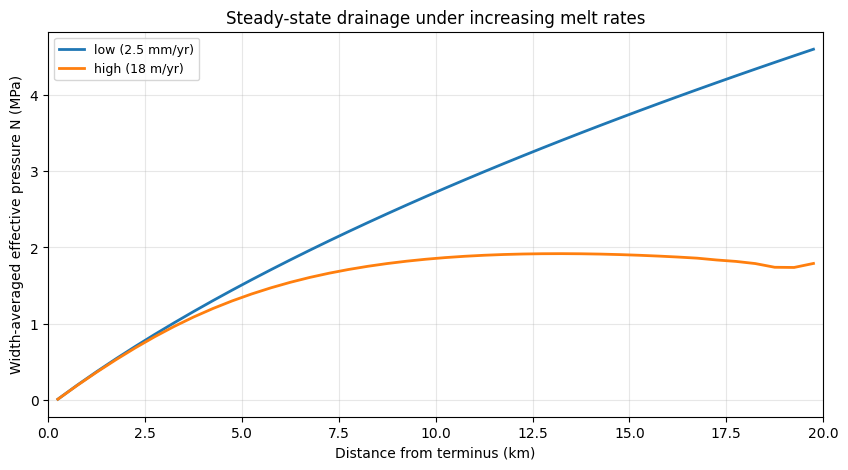

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, (xc, Nx, rate) in results.items():
    ax.plot(xc / 1e3, Nx / 1e6, lw=2, label=label)
ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width-averaged effective pressure N (MPa)")
ax.set_title("Steady-state drainage under increasing melt rates")
ax.set_xlim(0, 20)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3);

## Visualising the channel network

The channel area $S$ lives on mesh edges (CR1 space).
`hydropack.plot.tripcolor_cr` draws each edge as a colored line segment — the CR1 analogue of `firedrake.tripcolor`.

Let's compare the lowest and highest melt cases.
At low melt, $S \approx 0$ everywhere.
At peak summer, a dendritic channel network extends from the terminus upstream.

/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


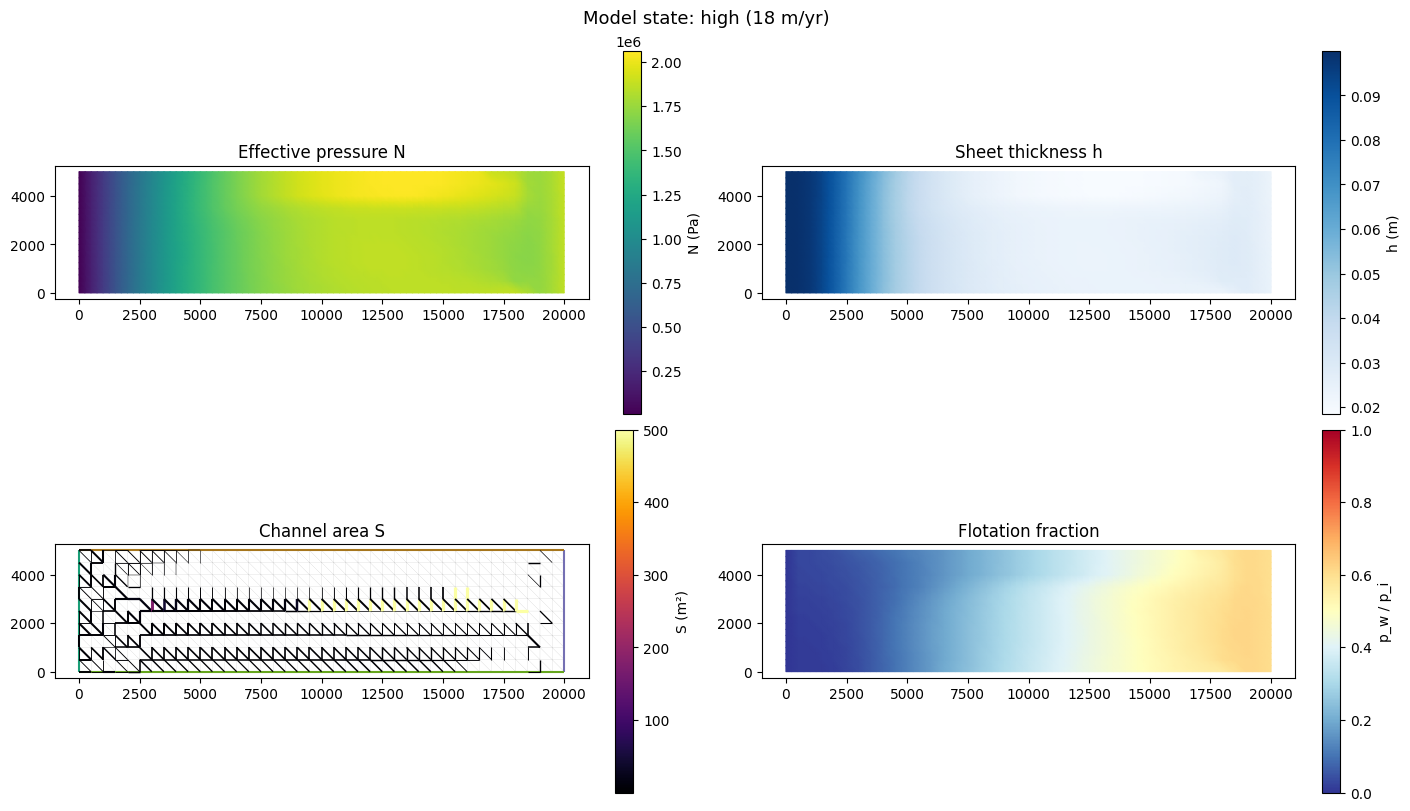

In [4]:
# Visualise the highest-melt case: N, h, S, and flotation fraction
labels = list(models.keys())
model_high = models[labels[-1]]
model_high.update_phi()
model_high.compute_flux_fields()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# Effective pressure
ax = axes[0, 0]
c = fd.tripcolor(model_high.N, axes=ax, cmap="viridis")
fig.colorbar(c, ax=ax, label="N (Pa)")
ax.set_title("Effective pressure N")
ax.set_aspect("equal")

# Sheet thickness
ax = axes[0, 1]
c = fd.tripcolor(model_high.h, axes=ax, cmap="Blues")
fig.colorbar(c, ax=ax, label="h (m)")
ax.set_title("Sheet thickness h")
ax.set_aspect("equal")

# Channel area on edges
ax = axes[1, 0]
fd.triplot(model_high.mesh, axes=ax, interior_kw={"linewidth": 0.1, "alpha": 0.2})
lc = hplot.tripcolor_cr(model_high.S, axes=ax, cmap="inferno", threshold=0.01)
fig.colorbar(lc, ax=ax, label="S (m²)")
ax.set_title("Channel area S")
ax.set_aspect("equal")

# Flotation fraction
ax = axes[1, 1]
model_high.update_pfo()
c = fd.tripcolor(model_high.pfo, axes=ax, cmap="RdYlBu_r", vmin=0, vmax=1)
fig.colorbar(c, ax=ax, label="p_w / p_i")
ax.set_title("Flotation fraction")
ax.set_aspect("equal")

fig.suptitle(f"Model state: {labels[-1]}", fontsize=13);

## Conclusion

The morphology of the drainage system controls the efficiency of the drainage system (channels transport water efficiently while sheets transport water inefficiently) and this drainage efficiency controls how effective pressure evolves with the melt water input.

**Low melt** → sheet handles all drainage → high effective pressure → fast sliding (poorly connected cavities maintain high water pressure away from the terminus).

**High melt** → channels develop → efficient drainage lowers water pressure → slower sliding (the "self-regulating" response).

This is why Greenland ice velocities often *decrease* in late summer even though melt is still high: the channel network has had time to develop and drain the bed efficiently.

The channel equations add significant complexity — discrete conduits on mesh edges, coupled to the sheet through flux exchange and shared pressure — but they are essential for any scenario with substantial melt input.

In the [next tutorial](03-moulins.ipynb) we add **moulins** — discrete point sources that deliver surface melt directly to the bed — and see how concentrated water input creates a very different channel network from the uniform-melt case here.

### Things to try

**conductivity** Increase the channel conductivity $k_c$ and observe how channels form more easily.

**ice rheology** Pass a custom `sheet_closure` function that uses a different rheology (e.g., $n = 4$ instead of 3).